In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def get_data_loaders(batch_size=64):
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00291/airfoil_self_noise.dat'
    data = pd.read_csv(url, sep='\t', header=None)
    
    # Chuẩn hóa (Z-score)
    data = (data - data.mean()) / data.std()
    
    features = torch.tensor(data.iloc[:, :-1].values, dtype=torch.float32)
    labels = torch.tensor(data.iloc[:, -1].values, dtype=torch.float32).reshape(-1, 1)
    
    dataset = TensorDataset(features, labels)
    return DataLoader(dataset, batch_size, shuffle=True), features.shape[1]

def train_model(config):
    # Lấy dữ liệu
    train_iter, input_dim = get_data_loaders(config['batch_size'])
    
    # Model & Loss
    model = nn.Linear(input_dim, 1)
    loss_fn = nn.MSELoss()
    
    # Optimizer
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config['lr'],
    )
    
    loss_history = []
    
    print(f"Bắt đầu huấn luyện: lr={config['lr']}")
    
    for epoch in range(config['epochs']):
        epoch_loss = 0
        for X, y in train_iter:
            optimizer.zero_grad()
            l = loss_fn(model(X), y)
            l.backward()
            optimizer.step()
            epoch_loss += l.item()
        
        avg_loss = epoch_loss / len(train_iter)
        loss_history.append(avg_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{config['epochs']} | Loss: {avg_loss:.4f}")
            
    return loss_history

def plot_loss(loss_history, config):
    plt.figure(figsize=(4, 3))
    plt.plot(loss_history, label=f"lr={config['lr']}")
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.grid(True)
    plt.show()

Bắt đầu huấn luyện: lr=0.01
Epoch 10/20 | Loss: 0.4870
Epoch 20/20 | Loss: 0.4886


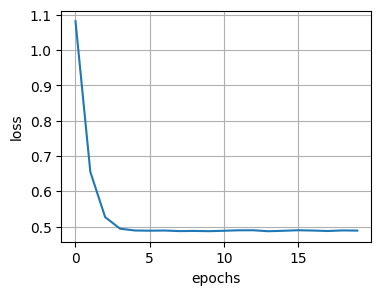

In [5]:
config = {
    'lr': 0.01,
    'batch_size': 32,   # Kích thước lô
    'epochs': 20        # Số vòng lặp
}

history = train_model(config)
plot_loss(history, config)

Bắt đầu huấn luyện: lr=0.05
Epoch 10/20 | Loss: 0.4970
Epoch 20/20 | Loss: 0.4986


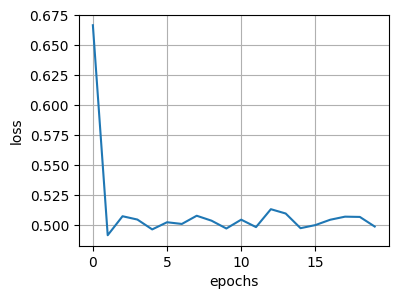

In [6]:
config = {
    'lr': 0.05,
    'batch_size': 32,   # Kích thước lô
    'epochs': 20        # Số vòng lặp
}

history = train_model(config)
plot_loss(history, config)

Bắt đầu huấn luyện: lr=0.005
Epoch 10/20 | Loss: 0.4880
Epoch 20/20 | Loss: 0.4859


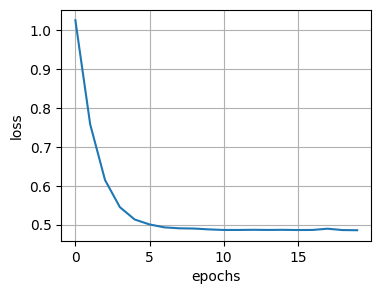

In [7]:
config = {
    'lr': 0.005,
    'batch_size': 32,   # Kích thước lô
    'epochs': 20        # Số vòng lặp
}

history = train_model(config)
plot_loss(history, config)

Bắt đầu huấn luyện: lr=0.0025
Epoch 10/50 | Loss: 0.5492
Epoch 20/50 | Loss: 0.4898
Epoch 30/50 | Loss: 0.4855
Epoch 40/50 | Loss: 0.4852
Epoch 50/50 | Loss: 0.4847


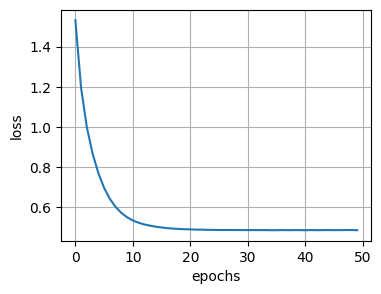

In [10]:
config = {
    'lr': 0.0025,
    'batch_size': 32,   # Kích thước lô
    'epochs': 50        # Số vòng lặp
}

history = train_model(config)
plot_loss(history, config)

Bắt đầu huấn luyện: lr=0.001
Epoch 10/50 | Loss: 0.7311
Epoch 20/50 | Loss: 0.5472
Epoch 30/50 | Loss: 0.5025
Epoch 40/50 | Loss: 0.4907
Epoch 50/50 | Loss: 0.4863


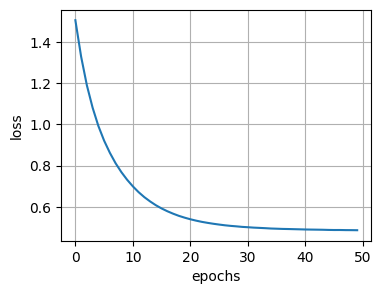

In [11]:
config = {
    'lr': 0.001,
    'batch_size': 32,   # Kích thước lô
    'epochs': 50        # Số vòng lặp
}

history = train_model(config)
plot_loss(history, config)